In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from scipy.stats import skew, kurtosis

In [54]:
current_dir = Path.cwd()

file_path = current_dir.parent / 'data' / 'raw' / 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

data = pd.read_csv(file_path)

In [55]:
print(data.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

**PHÂN TÍCH ĐƠN BIẾN**

In [ ]:
# Chuyển cột TotalCharges từ object về numerical
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors='coerce')

print("Số dòng bị Nan của cột TotalCharges:", data["TotalCharges"].isnull().sum())

data["TotalCharges"] = data["TotalCharges"].fillna(0)

Số dòng bị Nan của cột TotalCharges: 11


In [57]:
# Lấy các cột numerical
num_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]
num_df = data[num_cols]
print(num_df)

      tenure  MonthlyCharges  TotalCharges
0          1           29.85         29.85
1         34           56.95       1889.50
2          2           53.85        108.15
3         45           42.30       1840.75
4          2           70.70        151.65
...      ...             ...           ...
7038      24           84.80       1990.50
7039      72          103.20       7362.90
7040      11           29.60        346.45
7041       4           74.40        306.60
7042      66          105.65       6844.50

[7043 rows x 3 columns]


In [58]:
# Thống kê mô tả
num_df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [59]:
print(f"Chỉ số Kurtosis của tenure, MonthlyCharges, TotalCharges lần lượt là: {kurtosis(num_df)}")
print(f"Chỉ số Skewness của tenure, MonthlyCharges, TotalCharges lần lượt là: {skew(num_df)}")

Chỉ số Kurtosis của tenure, MonthlyCharges, TotalCharges lần lượt là: [-1.38723869 -1.2572191  -0.22926935]
Chỉ số Skewness của tenure, MonthlyCharges, TotalCharges lần lượt là: [ 0.23948873 -0.22047746  0.9630295 ]


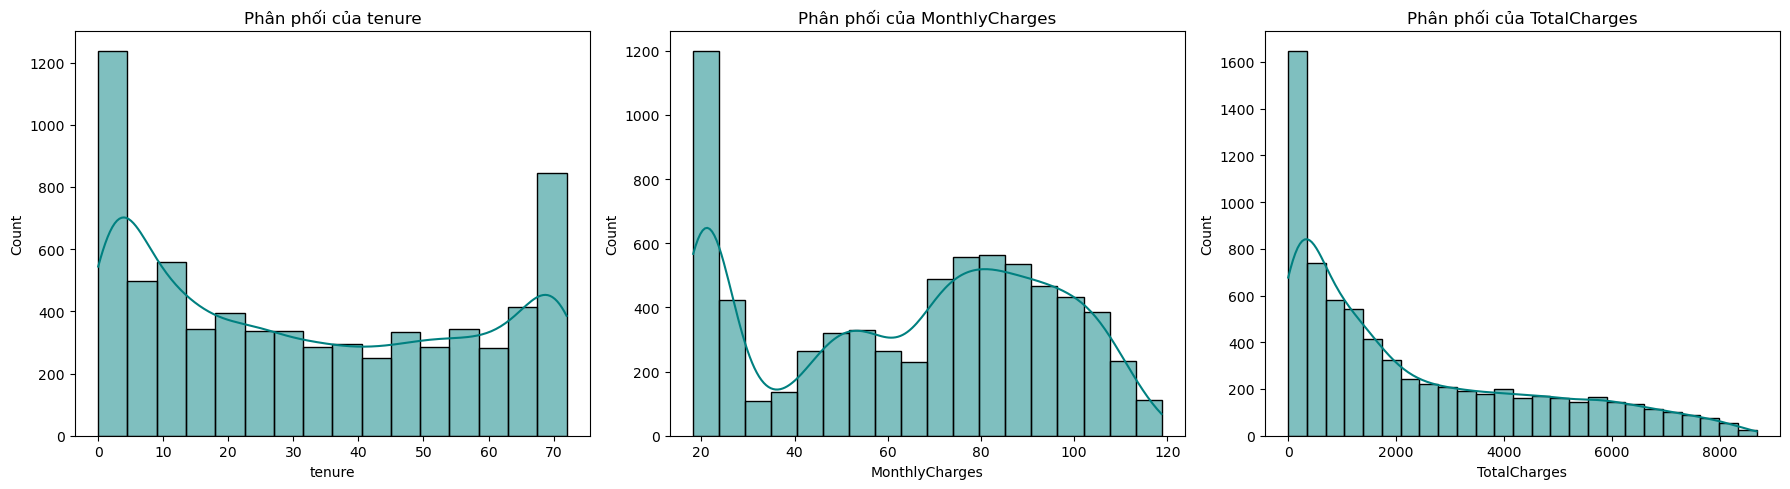

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(18 , 5))

for i, col in enumerate(num_cols):
    sns.histplot(data=num_df, x=col, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f"Phân phối của {col}")
    
plt.tight_layout()
plt.show()

**Nhận xét:**
- tenure:
    + skewness = 0.23948873: con số này gần 0, cho thấy được dữ liệu không bị lệch hẳn về nhóm khác hàng nào và khá đối xứng
    + kurtosis = -1.38723869: (âm khá sâu) con số này thể hiện tenure có phân phối bẹt, cho thấy dữ liệu không có một đỉnh trung tâm rõ ràng, và phân bố thành hình chữ U. Tập trung đông ở nhóm khách hàng (0 - 5) tháng và (72 - 75) tháng.

- MonthlyCharges:
    + skewness = -0.22047746: con số này gần 0, tương tự với skewness của biến tenure
    + kurtosis = -1.2572191: (âm khá sâu), biến này có phân phối bẹt. Nhìn vào biểu đồ ta thấy các giá trị được dàn trải đều và số tiền nhiều khách hàng trả hàng tháng nhất là (18 - 23) và số tiền ít khách hàng trả hàng tháng nhất là (31 - 36).

- TotalCharges:
    + skewness = 0.9630295, skewness dương và gần bằng 1 cho thấy biểu đồ phân bố lệch về bên hẳn về bên trái. Tổng số tiền phải trả của khách tập trung nhiều ở mức thấp nhất là 0 - 350, và giảm dần ở các mức giá lớn hơn. Chỉ có vài nhóm nhỏ là xài lâu năm nên tổng tiền tích lũy đạt từ 8000 trở lên. 
    + kurtosis = -0.22926935, phân phối bẹt và thấp hơn một xíu so với phân phối chuẩn và ít giá trị ngoại lai xuất hiện khi các về sau giá trị càng ít dần.

In [67]:
cat_cols = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

# Chuyển các cột từ object về categorical
for col in cat_cols:
    data[col] = data[col].astype('category')

/tmp/ipykernel_6964/643361050.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, ax=axes[i], palette='viridis')
/tmp/ipykernel_6964/643361050.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, ax=axes[i], palette='viridis')
/tmp/ipykernel_6964/643361050.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, ax=axes[i], palette='viridis')
/tmp/ipykernel_6964/643361050.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign 

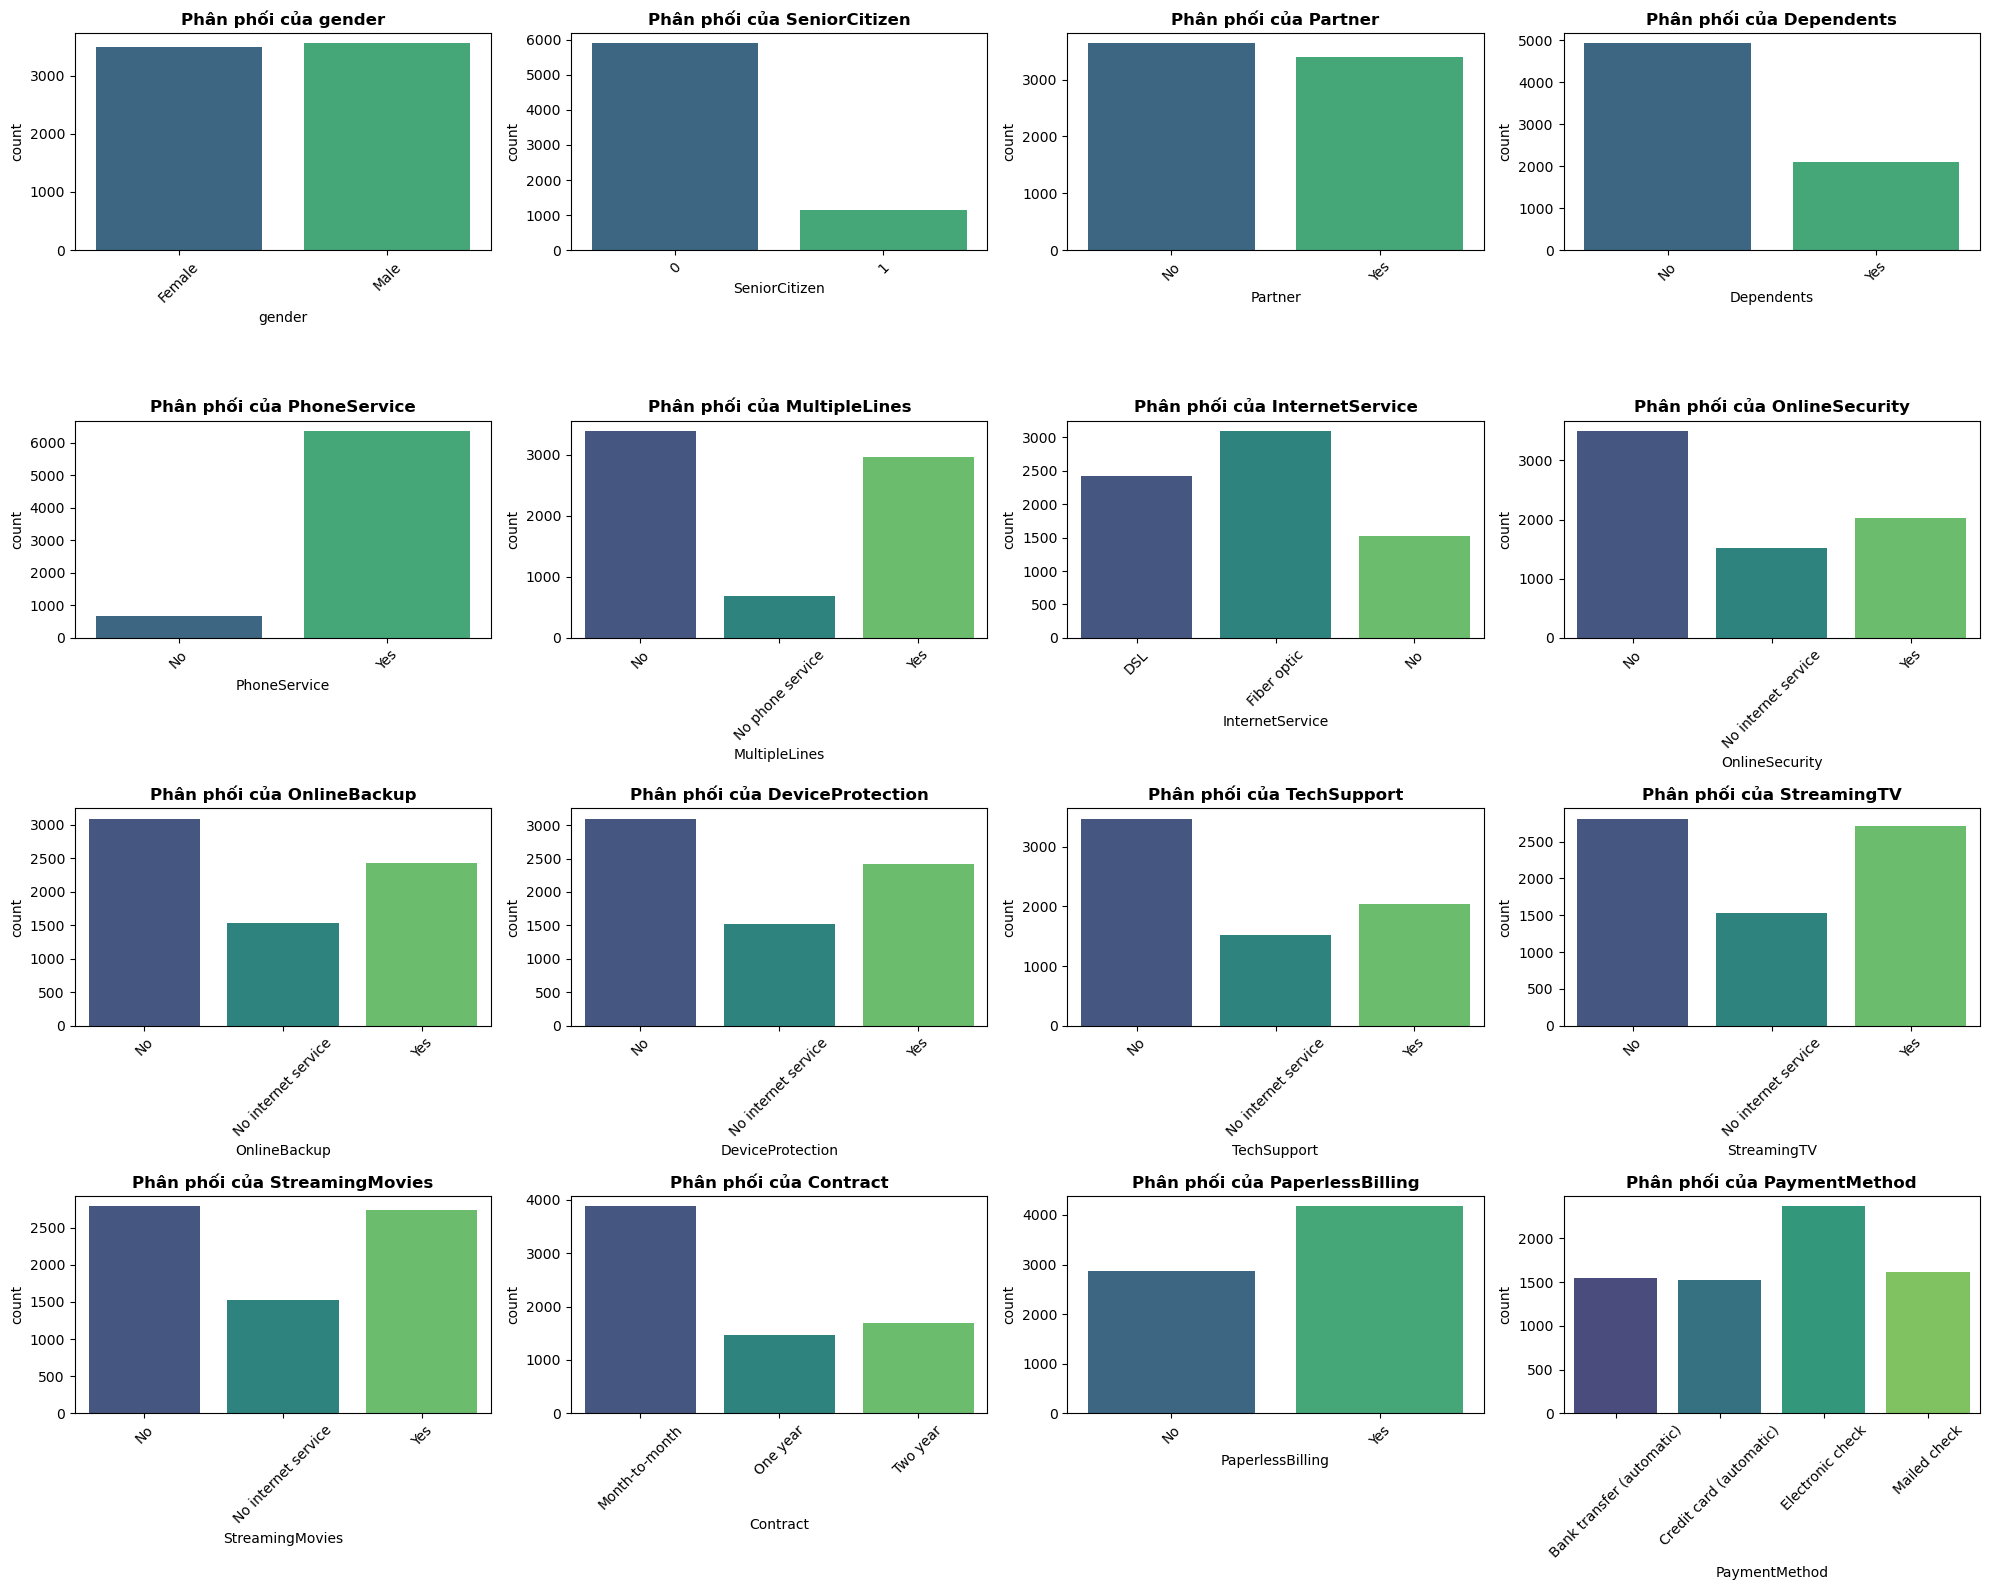

In [71]:
fig, axes = plt.subplots(nrows = 4, ncols = 4, figsize=(20, 16))

axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=data, x=col, ax=axes[i], palette='viridis')
    axes[i].set_title(f"Phân phối của {col}", fontsize=12, fontweight='bold')
    
    axes[i].tick_params(axis='x', rotation=45)
    
plt.tight_layout()
plt.show()

**Nhận xét:**
- PhoneService (Dịch vụ điện thoại): Cột "Yes" cao áp đảo hoàn toàn "No". Gần như 90% khách hàng trong tập dữ liệu này đều sử dụng điện thoại.

- SeniorCitizen (Người cao tuổi): Khách hàng trẻ (mức 0) chiếm đại đa số. Tập khách hàng của công ty này khá trẻ.

- Contract (Loại hợp đồng): Hợp đồng "Month-to-month" (Từng tháng một) cao gấp đôi, thậm chí gấp ba so với hợp đồng 1 năm hay 2 năm.

        => Khách hàng ký hợp đồng từng tháng không có sự ràng buộc lâu dài, nên họ là nhóm có nguy cơ rời bỏ (Churn) cao nhất.

- Dependents (Người phụ thuộc): Nhóm "No" (Không có người phụ thuộc - thường là độc thân hoặc chưa có con) cao hơn gấp đôi nhóm "Yes".

- Các dịch vụ đi kèm như OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport:

    + Cột "No" luôn cao hơn hẳn cột "Yes"
    
        => Điều này chứng tỏ công ty viễn thông này đang gặp khó khăn trong việc bán chéo các dịch vụ gia tăng cho khách hàng. Đa số khách hàng chỉ xài mạng Internet cơ bản chứ không mua thêm bảo mật hay hỗ trợ kỹ thuật.

**Phân tích song biến**

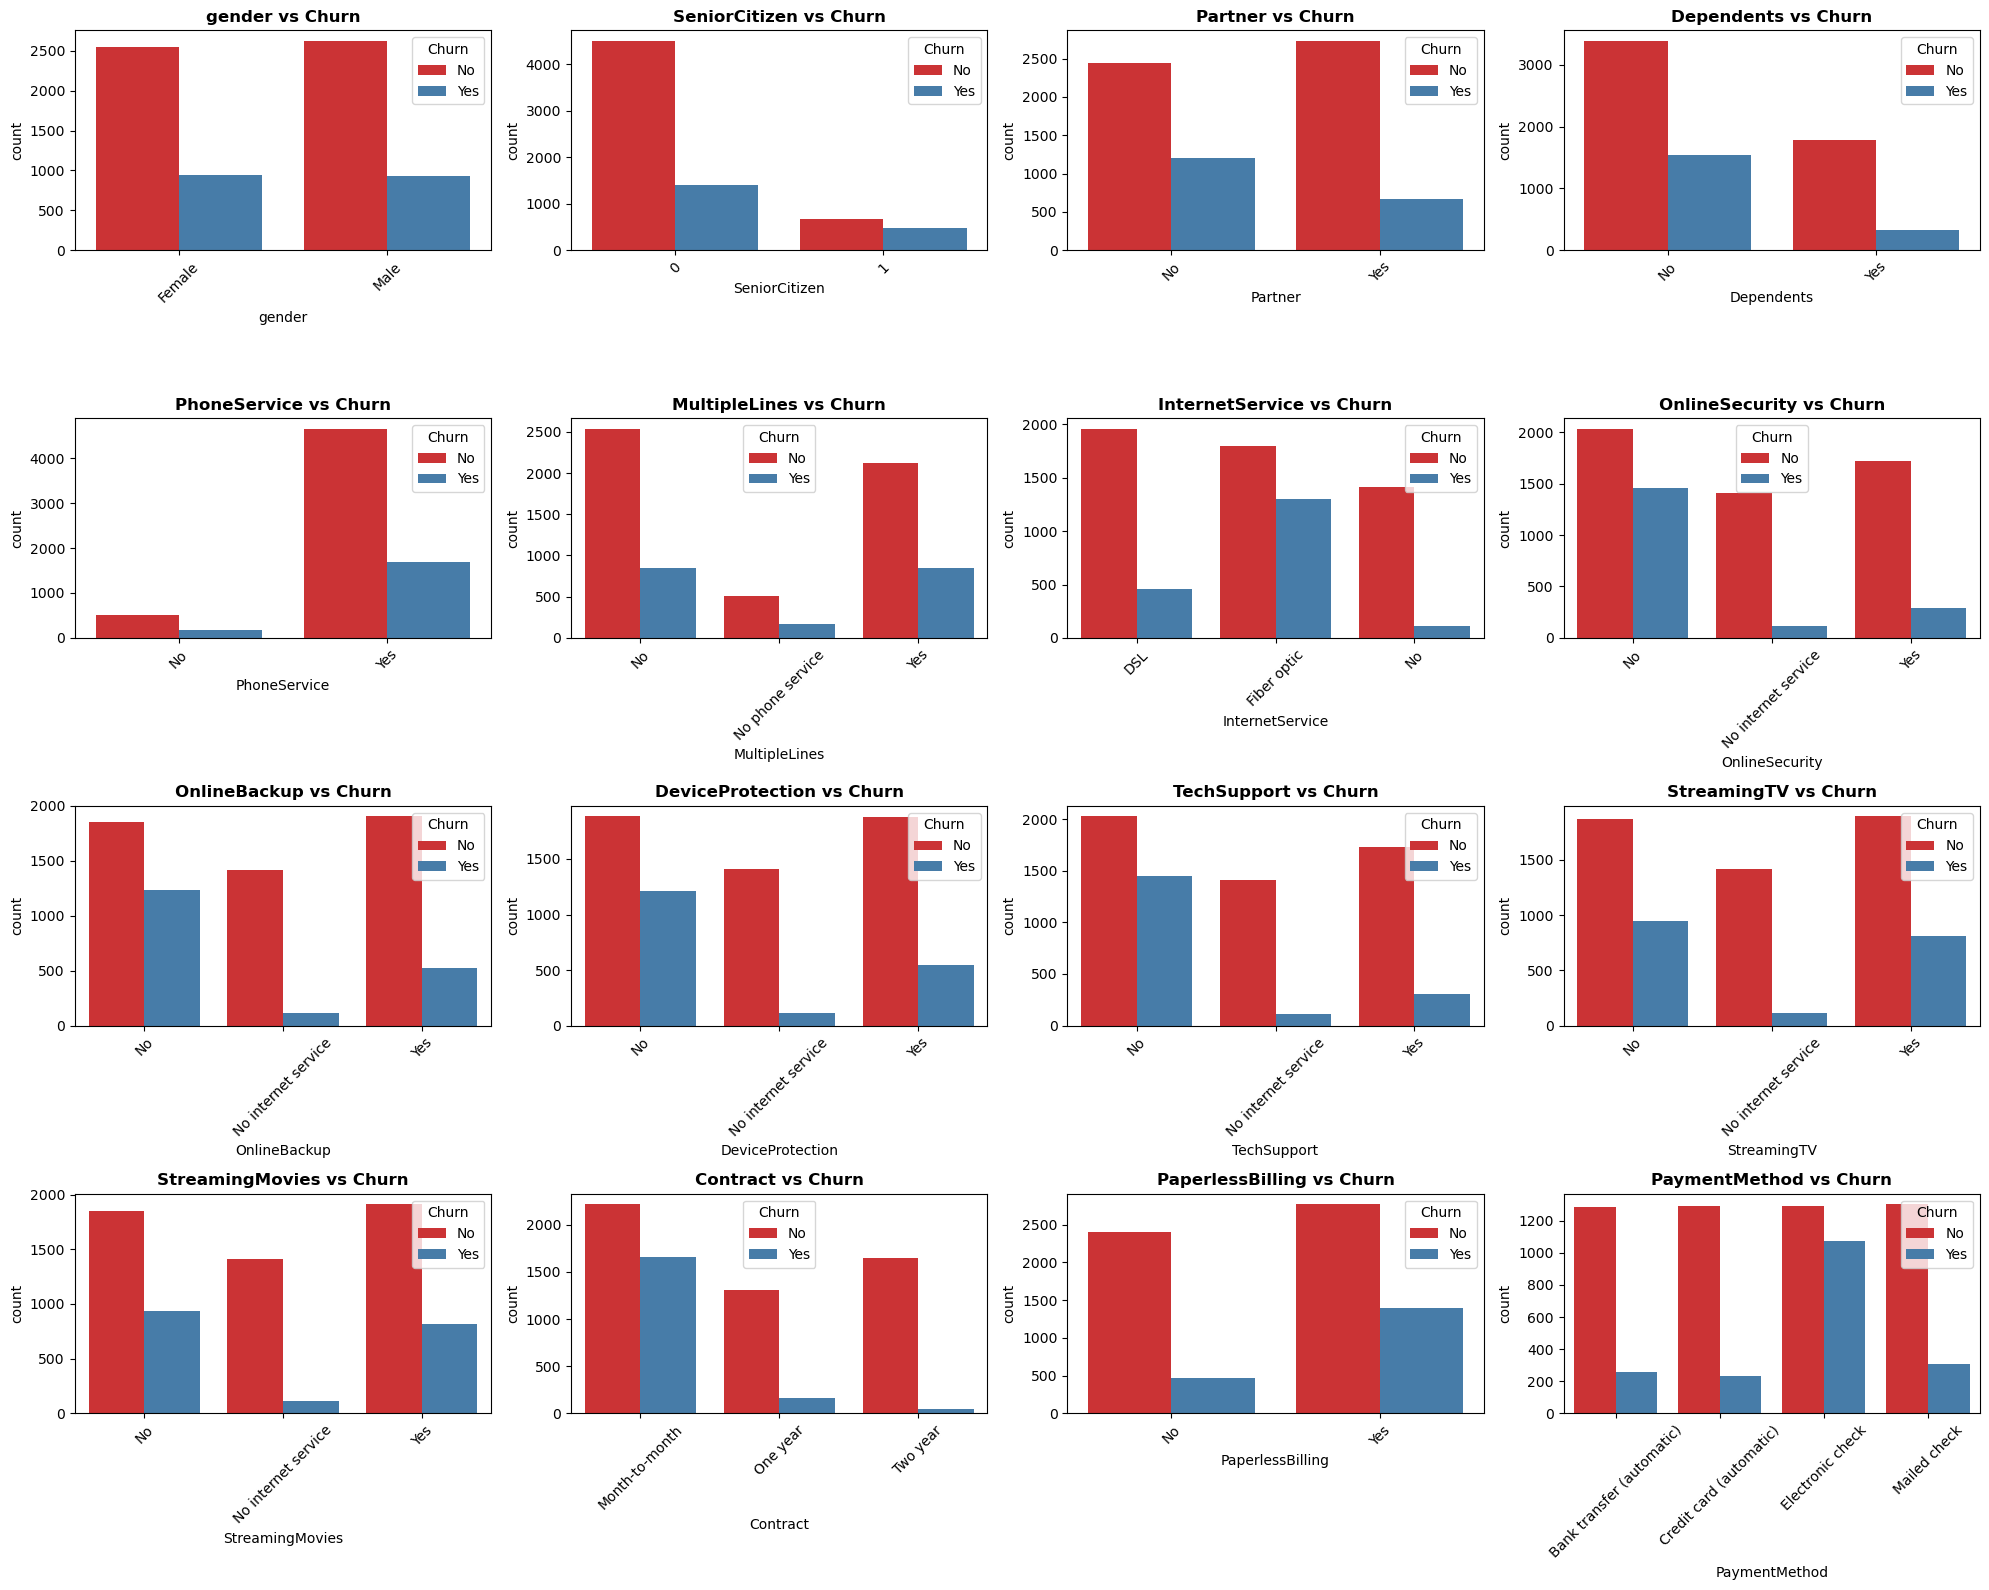

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tạo khung hình 4x4
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 16))
axes = axes.flatten()

# Vẽ 16 biểu đồ có phân loại theo Churn
for i, col in enumerate(cat_cols):
    # Thêm hue='Churn' để tách màu cho nhóm Yes/No
    sns.countplot(data=data, x=col, hue='Churn', ax=axes[i], palette='Set1')
    
    axes[i].set_title(f'{col} vs Churn', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Nhận xét:**
1. Nhóm các đặc điểm gây Churn mạnh nhất

    Contract (Hợp đồng Từng tháng): Cột Xanh cao gần bằng cột Đỏ. Việc không có ràng buộc thời gian khiến họ rời đi rất dễ dàng.

    PaymentMethod (Electronic check): Tỷ lệ khách hàng dùng Séc điện tử rời đi cao đột biến so với các hình thức thanh toán khác như Thẻ tín dụng hay Chuyển khoản ngân hàng. Có thể hệ thống thanh toán này đang bị lỗi, trải nghiệm người dùng kém, hoặc có phí ẩn khiến khách hàng bực mình,... 

    InternetService (Cáp quang - Fiber optic): Khách hàng dùng Cáp quang (đáng lẽ phải nhanh hơn) lại có tỷ lệ rời đi cao hơn hẳn nhóm dùng Cáp đồng (DSL). Rất có thể giá Cáp quang của công ty quá đắt hoặc chất lượng đường truyền không ổn định so với đối thủ.

2. Nhóm các đặc điểm giúp giữ chân khách hàng

    Dịch vụ gia tăng (OnlineSecurity, TechSupport, OnlineBackup): nhìn vào cột "No" của các dịch vụ này – tỷ lệ Churn cực kỳ cao. Ngược lại, những khách hàng đã mua gói "Bảo mật" hoặc "Hỗ trợ kỹ thuật" ("Yes") lại gắn bó rất lâu.

        => Công ty cần tung ra các gói Combo Internet kèm Bảo mật/Hỗ trợ để giữ khách hàng.

    Đặc điểm gia đình (Partner, Dependents): Khách hàng độc thân (No) có xu hướng hủy dịch vụ nhiều hơn nhóm có gia đình/người phụ thuộc (Yes). Nhóm gia đình thường thích sự ổn định.

3. Nhóm ít có giá trị dự đoán

    gender (Giới tính): Tỷ lệ rời đi của Nam và Nữ gần như y chang nhau. Giới tính không ảnh hưởng đến quyết định hủy mạng.

    PhoneService: Sự chênh lệch giữa hai nhóm Yes/No không mang lại nhiều thông tin giá trị.

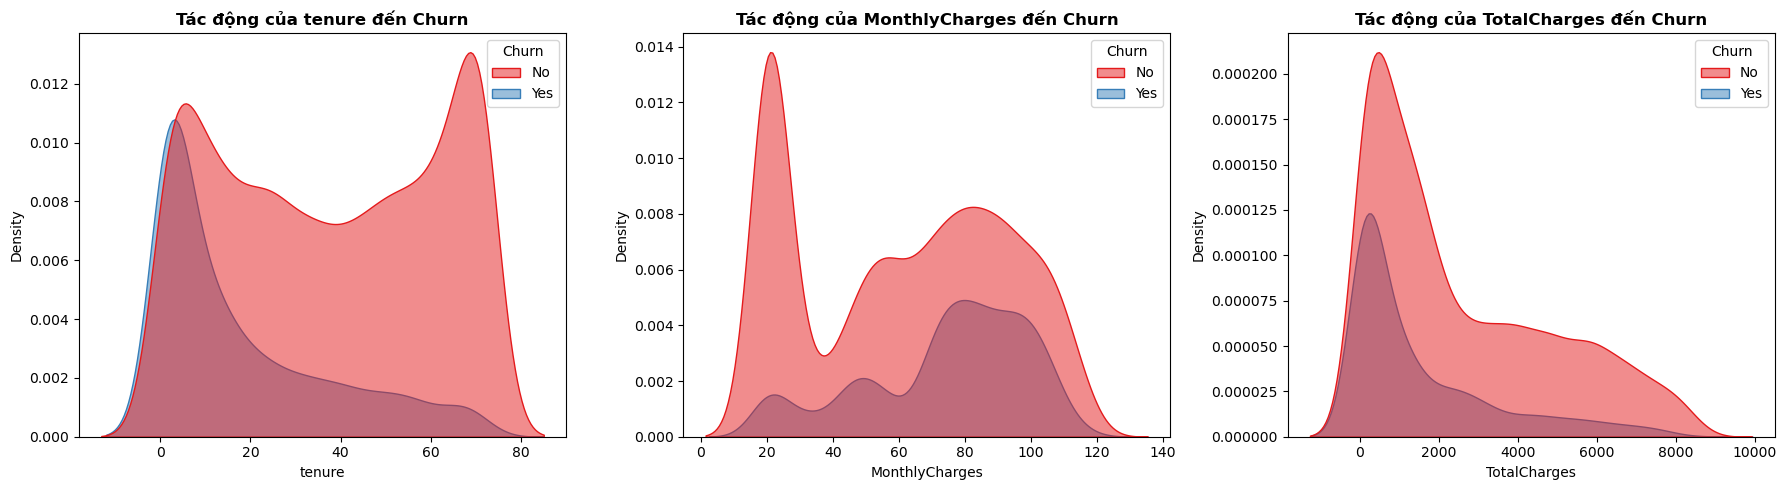

In [73]:
# Tạo khung hình 1 hàng 3 cột
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    # KDE Plot với hue='Churn' để xem hình dáng phân phối của 2 nhóm
    sns.kdeplot(data=data, x=col, hue='Churn', fill=True, ax=axes[i], palette='Set1', alpha=0.5)
    axes[i].set_title(f'Tác động của {col} đến Churn', fontweight='bold')

plt.tight_layout()
plt.show()

**Nhận xét:**
1. Biểu đồ tenure (Thời gian gắn bó)

    Vùng rủi ro cao nhất: đỉnh màu xanh (Yes) vút lên cực cao ở khoảng 0 - 10 tháng đầu tiên. Điều này cho thấy khách hàng có xu hướng hủy dịch vụ rất sớm ngay sau khi đăng ký. Nếu công ty viễn thông này không có chiến lược chăm sóc đặc biệt trong nửa năm đầu, họ sẽ mất đi một lượng lớn khách mới.

    Nhóm trung thành: Ngược lại, vùng màu đỏ (No) có một đỉnh rất to ở cuối trục (mốc 70 tháng). Nếu khách hàng đã "sống sót" qua được giai đoạn đầu, họ có xu hướng ở lại cực kỳ lâu dài.

2. Biểu đồ MonthlyCharges (Phí hàng tháng)

    Gói cước rẻ là ưu tiên của khách hàng: Vùng màu đỏ vươn lên thành một đỉnh khổng lồ ở mốc ~20$. Đây là nhóm khách hàng chỉ dùng gói cơ bản nhất (thường là không có Internet). Nhóm này cực kỳ trung thành, vùng màu xanh (rời đi) ở mức giá này gần như bằng 0.

    Càng đắt càng dễ rời đi: Ở phân khúc đóng phí cao (từ 70$ đến 110$), phần diện tích màu xanh (Yes) phình to ra và bám rất sát phần màu đỏ. Khách hàng trả nhiều tiền hơn sẽ có kỳ vọng cao hơn, và nếu họ thấy dịch vụ không tương xứng (hoặc đối thủ có gói rẻ hơn), họ sẵn sàng rời đi ngay.

3. Biểu đồ TotalCharges (Tổng chi phí)

    Hình dáng của biểu đồ này chịu ảnh hưởng rất mạnh từ cột tenure. Đỉnh màu xanh tập trung rất nhiều ở gần số 0, đơn giản là vì khách hàng rời đi từ những tháng đầu tiên (tenure thấp) thì số tiền tổng cộng họ đã đóng (TotalCharges) cũng sẽ rất thấp.

**Phân tích đa biến:**

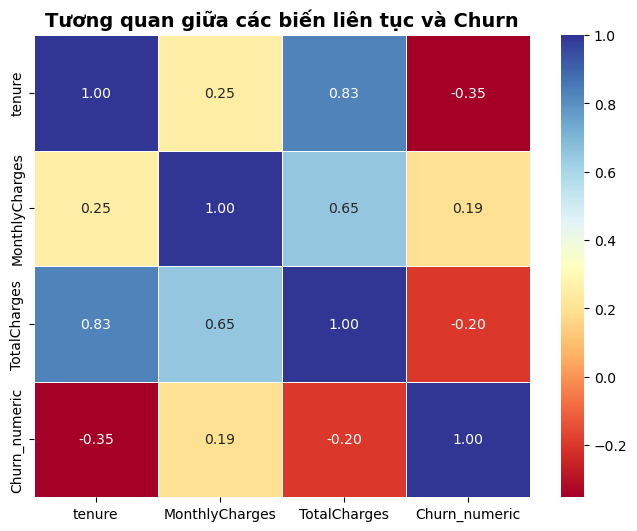

In [ ]:
df_corr = data.copy()

# Ép biến mục tiêu Churn thành 0 (No) và 1 (Yes)
df_corr['Churn_numeric'] = df_corr['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Gom 3 biến liên tục và biến Churn_numeric mới tạo
cols_to_plot = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_numeric']

# Tính ma trận và vẽ Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_corr[cols_to_plot].corr(), annot=True, cmap='RdYlBu', fmt=".2f", linewidths=0.5)
plt.title('Tương quan giữa các biến liên tục và Churn', fontsize=14, fontweight='bold')
plt.show()

**Nhận xét:**
- cột tenure và TotalCharges tương quan cao, cần loại bỏ 1 trong 2 cột, cột TotalCharges tương quan với cột MonthlyCharges cao hơn so với cột tenure. Và biến tenure cũng mang lại nhiêù giá trị hơn cho biến mục tiêu so với TotalCharges. => Loại bỏ cột **TotalCharges** và giữ lại **tenure, MonthlyCharges**